In [101]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [102]:
# Import data
niv = '3'

# HICP All Items
colHicp = "INX"

# Unchained other items 
dfICP = pd.read_parquet(f"input/unchainedItemsLvl{niv}.parquet")
dfW = pd.read_parquet(f"input/normedWeightsLvl{niv}.parquet") 

In [103]:
# We compute inflation rates on Unchained items
dfInflation = np.log(dfICP).diff(12)[12:]
InflTot = dfInflation["INX"].to_frame()
dfInflation = dfInflation.drop("INX",axis=1)

In [104]:
# Step 1 : AR(1) on a rolling window of 120 months
rolWind = 120

# Sub-sample
subInfl = dfInflation.iloc[:,:3]
item = "011100"
# for item in subInfl.columns:
window_data = subInfl[item].iloc[:120].ffill()
y = window_data.iloc[1:].values        # Inflation rate T
x = window_data.iloc[:-1].values       # Inflation rate lagged (T-1)
x = sm.add_constant(x)

# Régression linéaire pour obtenir le choc du mois courant
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     847.3
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.02e-55
Time:                        15:45:10   Log-Likelihood:                 508.56
No. Observations:                 119   AIC:                            -1013.
Df Residuals:                     117   BIC:                            -1008.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.056      0.2

In [105]:
residuals = model.resid
y = residuals[1:]      
x = residuals[:-1]     

# Régression linéaire pour obtenir le choc du mois courant
model = sm.OLS(y, x).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.079
Model:                            OLS   Adj. R-squared (uncentered):              0.071
Method:                 Least Squares   F-statistic:                              9.984
Date:                Fri, 18 Sep 2026   Prob (F-statistic):                     0.00201
Time:                        15:45:44   Log-Likelihood:                          508.62
No. Observations:                 118   AIC:                                     -1015.
Df Residuals:                     117   BIC:                                     -1012.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [113]:
def replicate_ismi(dfInflation, rolling_window=120, k=3):
    """Replication de l'indice ISMI (Lansing & Shapiro, 2026).

    df_inflation : DataFrame (Dates x Catégories) - Taux d'inflation mensuels
    df_weights   : DataFrame (Dates x Catégories) - Poids de dépenses (PCE)
    """
    categories = dfInflation.columns
    dates = dfInflation.index[rolling_window:]

    ismi_series = []
    pos_momentum_series = []
    neg_momentum_series = []

    # Stockage temporaire des chocs (résidus de l'AR(1))
    shocks_dict = {cat: pd.Series(index=dfInflation.index, dtype=float) for cat in categories}
    a_dict = {cat: pd.Series(index=dfInflation.index, dtype=float) for cat in categories}
    rho_dict = {cat: pd.Series(index=dfInflation.index, dtype=float) for cat in categories}

    print("Étape 1 : Estimation des chocs via AR(1) glissant...")
    for t_idx in range(rolling_window, len(dfInflation)):
        current_date = dfInflation.index[t_idx]

        for cat in categories:
            # Fenêtre glissante de 120 mois (Lansing & Shapiro, 2026)
            window_data = dfInflation[cat].iloc[t_idx - rolling_window : t_idx + 1]

            y = window_data.iloc[1:].values        # Inflation rate T
            x = window_data.iloc[:-1].values       # Inflation rate lagged (T-1)
            x = sm.add_constant(x)

            try:
                ### 2-step regressions                
                #   1) Régression linéaire pour obtenir le choc du mois courant
                model1 = sm.OLS(y, x).fit()
                residuals = model1.resid
                shocks_dict[cat].at[current_date] = residuals[-1]
                
                # Inflation AR(1) coefficient (constant)
                a_dict[cat].at[current_date] = model1.params[1]
                
                #   2) Régression résidus
                yRes = residuals[1:]        
                xRes = residuals[:-1]
            
                # Noise AR(1) coefficient (no constant)
                model2 = sm.OLS(yRes, xRes).fit()
                rho_dict[cat].at[current_date] = model2.params[0]
                
            except:
                a_dict[cat].at[current_date] = None
                rho_dict[cat].at[current_date] = None
                shocks_dict[cat].at[current_date] = None

    df_shocks = pd.DataFrame(shocks_dict)
    aCoef = pd.DataFrame(a_dict)
    rhoCoef = pd.DataFrame(rho_dict)


    # print("Étape 2 : Calcul du momentum et agrégation pondérée...")
    # for current_date in dates:
    #     # Récupérer l'historique récent des chocs pour la règle des k mois consécutifs
    #     t_pos = df_shocks.index.get_loc(current_date)
    #     recent_shocks = df_shocks.iloc[t_pos - k + 1 : t_pos + 1]

    #     # Détection des chocs directionnels consécutifs (ex: 3 mois positifs)
    #     pos_signal = (recent_shocks > 0).all(axis=0).astype(int)
    #     neg_signal = (recent_shocks < 0).all(axis=0).astype(int)

    #     # # Extraction des poids pour le mois en cours
    #     # w = df_weights.loc[current_date]
    #     # w_normalized = w / w.sum()

    #     # # Calcul des parts pondérées de momentum positive et négative
    #     # share_pos = np.dot(pos_signal, w_normalized)
    #     # share_neg = np.dot(neg_signal, w_normalized)

    #     # # ISMI = part positive - part négative
    #     # ismi = share_pos - share_neg
    #     ismi = pos_signal - neg_signal

    #     ismi_series.append(ismi)
    #     pos_momentum_series.append(share_pos)
    #     neg_momentum_series.append(share_neg)

    # results = pd.DataFrame(
    #     {
    #         "ISMI": ismi_series,
    #         "Positive_Momentum": pos_momentum_series,
    #         "Negative_Momentum": neg_momentum_series,
    #     },
    #     index=dates,
    # )

    return df_shocks, aCoef, rhoCoef

In [114]:
# Réplication Figure A1
_, aCoef, rhoCoef = replicate_ismi(InflTot, rolling_window=120)

# Drop NaN and merge
HICP = InflTot.copy()
HICP["A"] = aCoef.values
HICP["Rho"] = rhoCoef.values
HICP = HICP.dropna()
HICP

Étape 1 : Estimation des chocs via AR(1) glissant...


,INX,A,Rho
TIME_PERIOD,,,
2008-01-01,0.031494,0.937666,0.210977
2008-02-01,0.032118,0.941080,0.211273
2008-03-01,0.035172,0.953335,0.211995
2008-04-01,0.032136,0.946929,0.199149
2008-05-01,0.035999,0.959461,0.163781
...,...,...,...
2026-04-01,0.029847,0.979500,0.359292
2026-05-01,0.031220,0.979796,0.358142
2026-06-01,0.027156,0.979830,0.355393


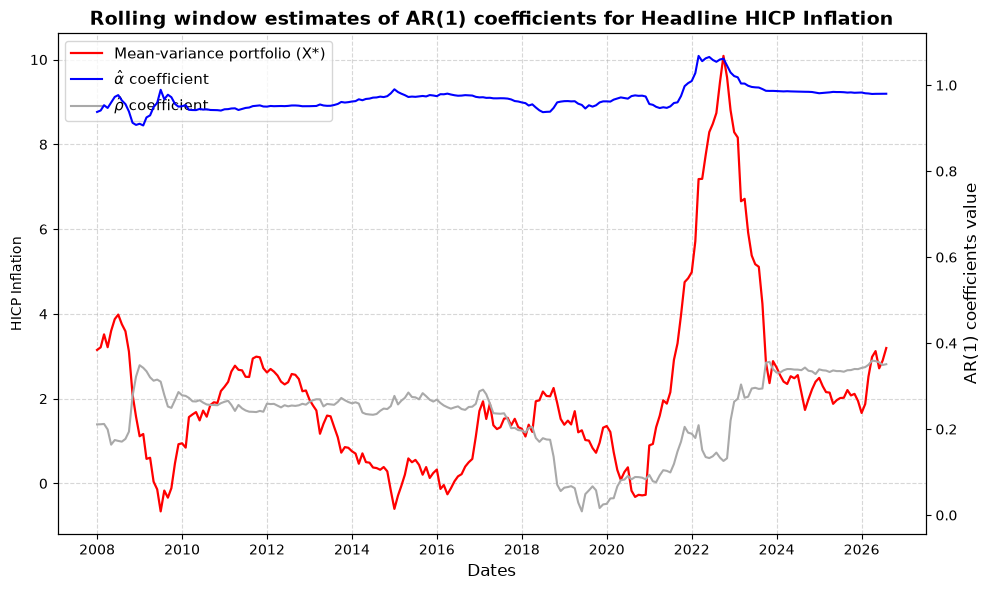

In [116]:
# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (HICP inflation - 12-month) ---
ax1.plot(
    HICP["INX"]*100,
    label="Mean-variance portfolio (X*)",
    color="red",
    linewidth=1.6,
)

ax1.set_xlabel("Dates", fontsize=12)
ax1.set_ylabel("HICP Inflation")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Right axis (AR coefficients) ---
ax2 = ax1.twinx()

ax2.plot(
    HICP["A"],
    label=r'$\hat \alpha$ coefficient',
    color="blue",
    linewidth=1.5,
)

ax2.plot(
    HICP["Rho"],
    label=r'$\hat \rho$ coefficient',
    color="darkgrey",
    linewidth=1.5,
)

ax2.set_ylabel("AR(1) coefficients value", fontsize=12)
ax2.tick_params(axis="y")

# --- Title, legend ---
plt.title("Rolling window estimates of AR(1) coefficients for Headline HICP Inflation", fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=11)

plt.tight_layout()
plt.show()

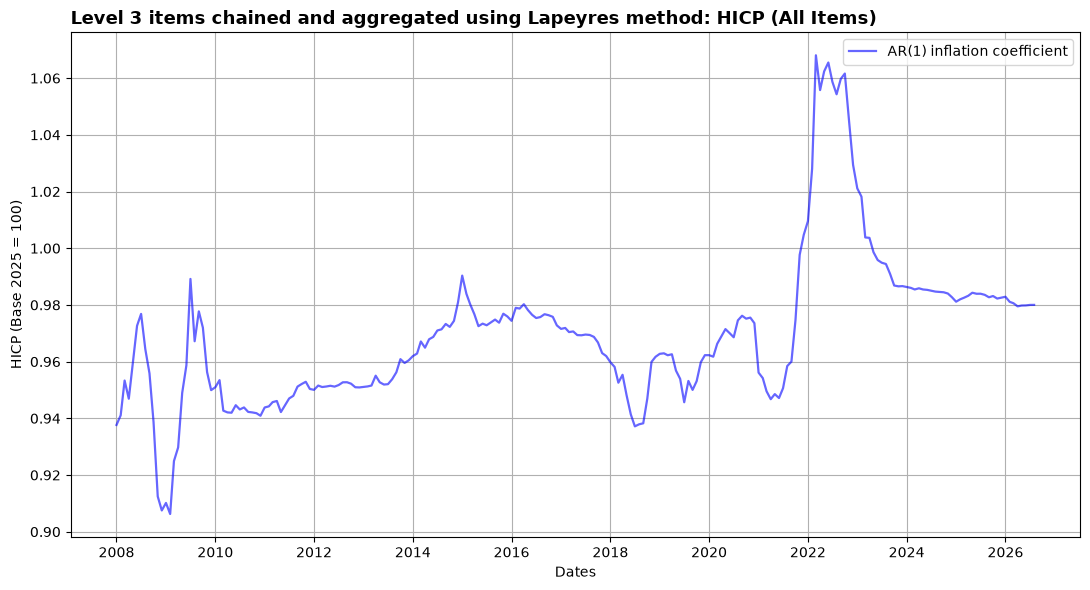

In [86]:
# Plot...
fig, ax = plt.subplots(figsize=(11, 6))

x_axis = InflTot.index

# ax.plot(x_axis, InflTot.values, color="black", lw=1.6, alpha=0.6, label="HICP Inflation (12-month)")
ax.plot(x_axis, aCoef.values, color="blue", lw=1.6, alpha=0.6, label="AR(1) inflation coefficient")
# ax.plot(x_axis, rhoCoef, color="red", lw=1.6, alpha=0.6, label="AR(1) residual coefficient")

# ax.plot(x_axis, dFinal.loc[dFinal.ecoicop == "00", "wINX"].values, color="#4C72B0", lw=1.6, ls="--", label=f"Level 0")
ax.set_title(f"Level {niv} items chained and aggregated using Lapeyres method: HICP (All Items)",
              fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Dates")
ax.set_ylabel("HICP (Base 2025 = 100)")
ax.legend(loc="best", fontsize=10)
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
categories = df_inflation.columns
dates = df_inflation.index[120:]

ismi_series = []
pos_momentum_series = []
neg_momentum_series = []

# Stockage temporaire des chocs (résidus de l'AR(1))
shocks_dict = {cat: pd.Series(index=df_inflation.index, dtype=float) for cat in categories}

print("Étape 1 : Estimation des chocs via AR(1) glissant...")
for t_idx in range(120, len(df_inflation)):
    current_date = df_inflation.index[t_idx]

    for cat in categories:
        # Fenêtre glissante de 120 mois (Lansing & Shapiro, 2026)
        window_data = df_inflation[cat].iloc[t_idx - rolling_window : t_idx + 1]

        y = window_data.iloc[1:]  # t
        x = window_data.iloc[:-1]  # t-1
        x = sm.add_constant(x)

        # Régression linéaire pour obtenir le choc du mois courant
        model = sm.OLS(y, x).fit()
        # Le dernier résidu correspond au choc du mois t
        shocks_dict[cat].at[current_date] = model.resid.iloc[-1]

df_shocks = pd.DataFrame(shocks_dict)